In [1]:
# Standard library
import os
import random

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from PIL import Image

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)

# Hyperspectral imaging
import spectral.io.envi as envi
from spectral import open_image

# Set random seed for reproducibility
SEED = 67
random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed: {SEED}")

Random seed: 67


In [2]:
# Configuration
DATA_DIR = "/home/alfi/projects/food-anomaly/AnomalyonFood/Dataset/Almond/Train"
TEST_DIR = "/home/alfi/projects/food-anomaly/AnomalyonFood/Dataset/Almond/Test"
N_COMPONENTS = 20  # Number of PCA components
NU = 0.1  # One-Class SVM parameter (fraction of outliers)
GAMMA = 'scale'  # Kernel coefficient
DECISION_PERCENTILE = 99  # Percentile for decision threshold

print(f"Using SEED={SEED} for reproducibility")
print(f"PCA components: {N_COMPONENTS}")
print(f"One-Class SVM nu: {NU}")
print(f"Kernel gamma: {GAMMA}")

def load_and_calibrate(data_dir):
    """
    Load hyperspectral data from data.hdr file.
    """
    # Locate data.hdr file
    data_file = None
    
    for f in os.listdir(data_dir):
        if f.endswith('.hdr') and "data" in f.lower():
            data_file = os.path.join(data_dir, f)
            break
    
    if not data_file:
        raise FileNotFoundError(f"data.hdr not found in {data_dir}")
    
    print(f"Loading data from {data_dir}:")
    print(f"  - Data: {os.path.basename(data_file)}")
    
    # Load the hyperspectral cube
    data = open_image(data_file).load().astype(np.float32)
    
    print(f"  - Data shape: {data.shape}")
    print(f"  - Data range: [{data.min():.4f}, {data.max():.4f}]")
    
    # Simple normalization to [0, 1] range
    data_min = data.min()
    data_max = data.max()
    if data_max > data_min:
        data = (data - data_min) / (data_max - data_min)
    
    print(f"  - Normalized range: [{data.min():.4f}, {data.max():.4f}]")
    
    return data

hsi_data = load_and_calibrate(DATA_DIR)
print(f"Data shape: {hsi_data.shape}")

Using SEED=67 for reproducibility
PCA components: 20
One-Class SVM nu: 0.1
Kernel gamma: scale
Loading data from /home/alfi/projects/food-anomaly/AnomalyonFood/Dataset/Almond/Train:
  - Data: data.hdr
  - Data shape: (400, 512, 224)


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


  - Data range: [287.0000, 1504.0000]
  - Normalized range: [0.0000, 1.0000]
Data shape: (400, 512, 224)



Training PCA + One-Class SVM (Unsupervised)

Training data shape: (204800, 224)
Fitting PCA with 20 components...
Explained variance: 0.9982 (99.82%)
PCA-transformed shape: (204800, 20)

Training One-Class SVM (nu=0.1, gamma=scale)...
One-Class SVM trained!

Decision threshold (99th percentile): 555.5610


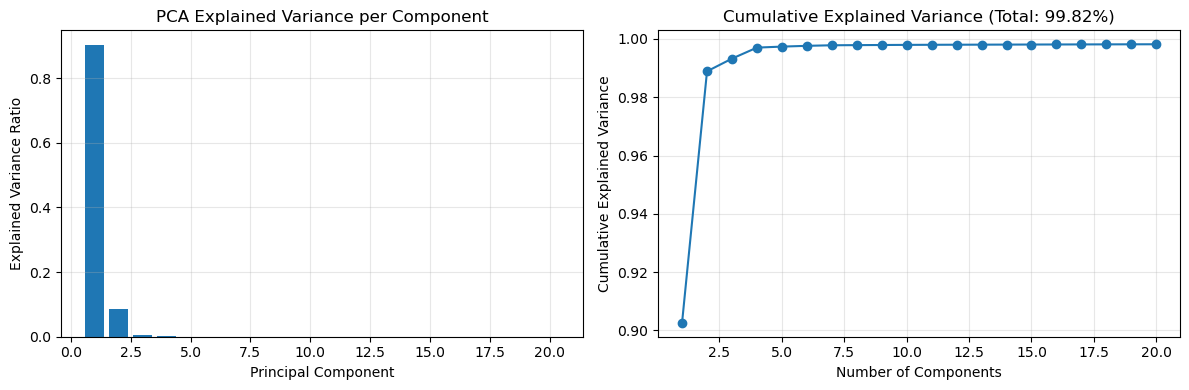


✅ Model trained successfully!


In [3]:
# Train PCA + One-Class SVM on training data
print("\n" + "="*60)
print("Training PCA + One-Class SVM (Unsupervised)")
print("="*60 + "\n")

h, w, b = hsi_data.shape

# Reshape to (pixels, bands)
pixels_train = hsi_data.reshape(-1, b)
print(f"Training data shape: {pixels_train.shape}")

# Fit PCA
pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
print(f"Fitting PCA with {N_COMPONENTS} components...")
pca.fit(pixels_train)

# Calculate explained variance
explained_var = np.sum(pca.explained_variance_ratio_)
print(f"Explained variance: {explained_var:.4f} ({explained_var*100:.2f}%)")

# Transform training data
pixels_train_pca = pca.transform(pixels_train)
print(f"PCA-transformed shape: {pixels_train_pca.shape}")

# Train One-Class SVM
print(f"\nTraining One-Class SVM (nu={NU}, gamma={GAMMA})...")
ocsvm = OneClassSVM(kernel='rbf', gamma=GAMMA, nu=NU)
ocsvm.fit(pixels_train_pca)
print("One-Class SVM trained!")

# Compute decision scores on training data for threshold selection
train_scores = ocsvm.decision_function(pixels_train_pca)
decision_threshold = np.percentile(train_scores, DECISION_PERCENTILE)
print(f"\nDecision threshold ({DECISION_PERCENTILE}th percentile): {decision_threshold:.4f}")

# Visualize explained variance
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(range(1, N_COMPONENTS+1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance per Component')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, N_COMPONENTS+1), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title(f'Cumulative Explained Variance (Total: {explained_var:.2%})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Model trained successfully!")

Inference & Visualization...
Loading data from /home/alfi/projects/food-anomaly/AnomalyonFood/Dataset/Almond/Test:
  - Data: data.hdr


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


  - Data shape: (400, 512, 224)
  - Data range: [286.0000, 1509.0000]
  - Normalized range: [0.0000, 1.0000]
Test Data shape: (400, 512, 224)
Test data reshaped: (204800, 224)
Transforming test data to PCA space...
Computing anomaly scores with One-Class SVM...


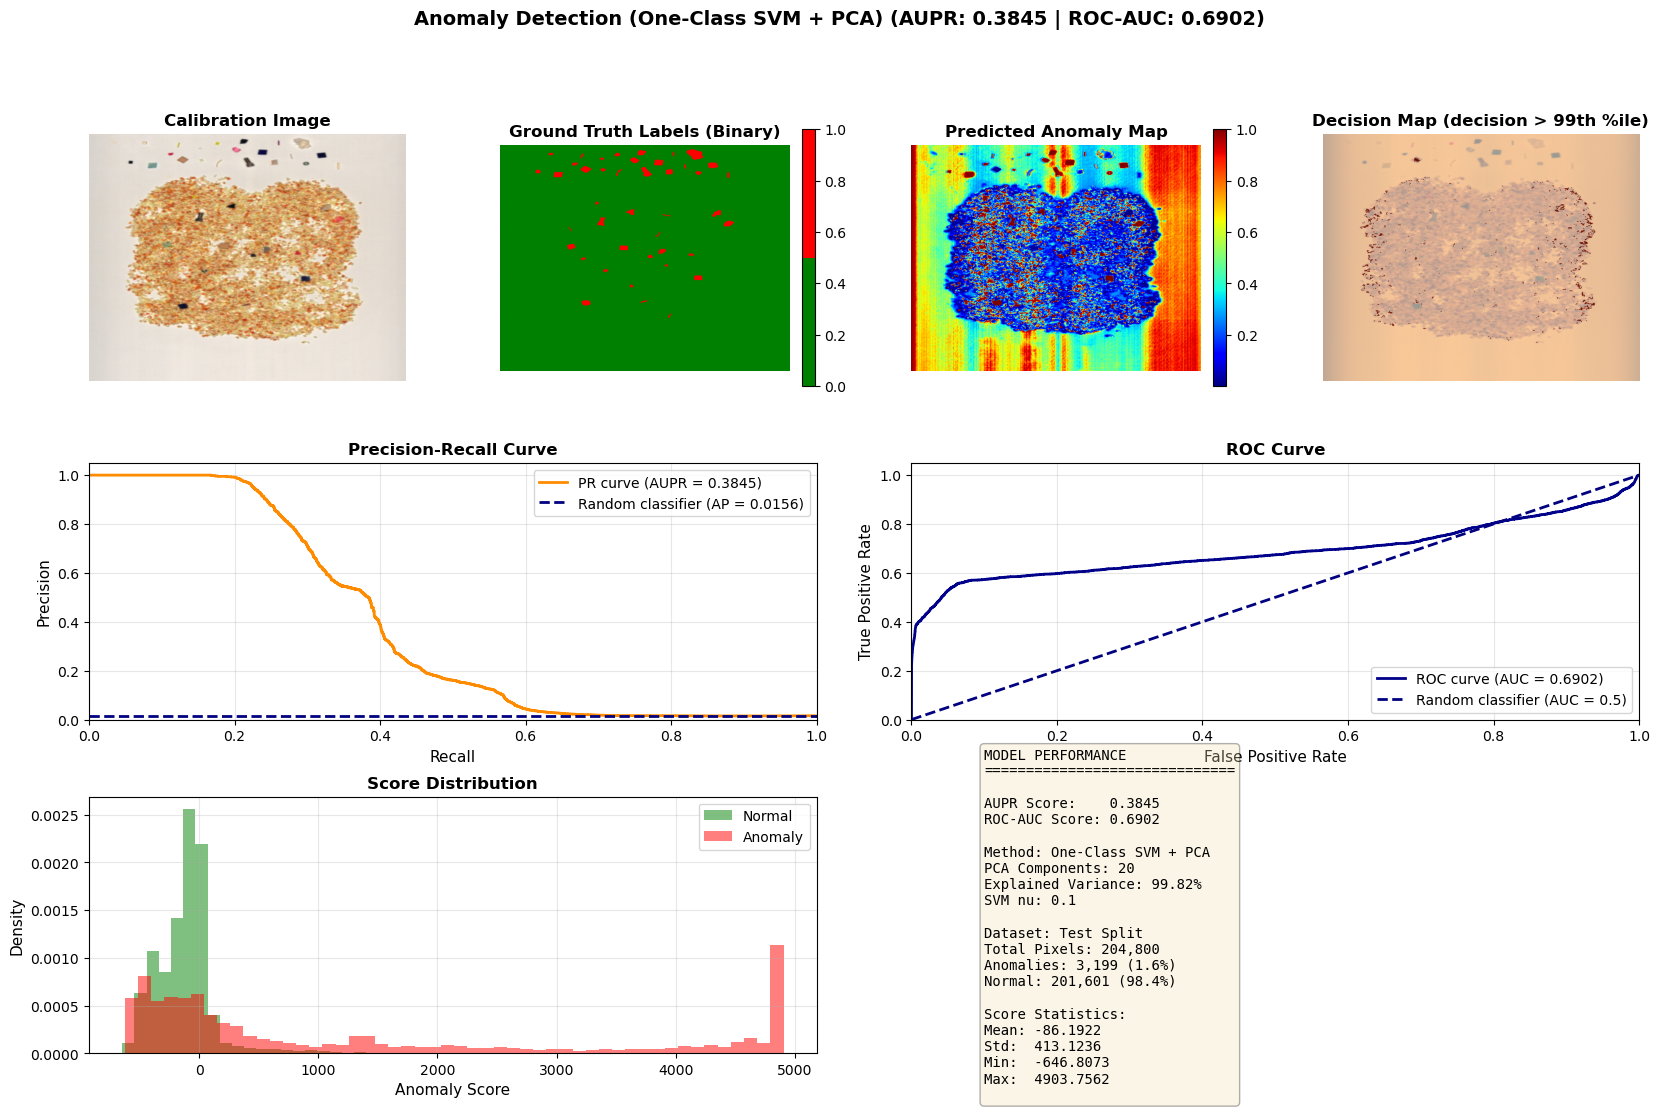


✅ Evaluation complete!
   AUPR Score: 0.3845
   ROC-AUC Score: 0.6902


In [6]:
print("Inference & Visualization...")
hsi_data_test = load_and_calibrate(TEST_DIR)
print(f"Test Data shape: {hsi_data_test.shape}")

h_test, w_test, b_test = hsi_data_test.shape

# Reshape test data to (pixels, bands)
pixels_test = hsi_data_test.reshape(-1, b_test)
print(f"Test data reshaped: {pixels_test.shape}")

# Transform to PCA space
print("Transforming test data to PCA space...")
pixels_test_pca = pca.transform(pixels_test)

# Get decision function scores
print("Computing anomaly scores with One-Class SVM...")
raw_decision_scores = ocsvm.decision_function(pixels_test_pca)

# Anomaly scores: higher decision_score = more normal, lower = more anomalous
# For metrics and decision: use raw scores directly
raw_anomaly_scores = -raw_decision_scores
anomaly_scores_flat = raw_anomaly_scores

# NOTE: Rank normalization is applied ONLY for visualization.
# ROC-AUC / PR-AUC depend only on score ordering, so metrics are unaffected.
from scipy.stats import rankdata
rank_anomaly_scores = rankdata(raw_anomaly_scores, method="average") / len(raw_anomaly_scores)

# Reshape rank scores to image for visualization
anomaly_map = rank_anomaly_scores.reshape(h_test, w_test)
final_error_map = anomaly_map  # already in [0, 1]

# Binary decision map - mark top 1% (99th percentile and above) as anomalies
decision_map = (raw_decision_scores > decision_threshold).reshape(h_test, w_test)
rgb_bands = [100, 60, 20] if b_test > 100 else [max(b_test - 1, 0), max(b_test // 2, 0), max(b_test // 3, 0)]
rgb_img = hsi_data_test[:, :, rgb_bands]
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)

# Optional label-based metrics if label.npy exists
label_path = os.path.join(TEST_DIR, "label.npy")
labels_available = os.path.exists(label_path)
if labels_available:
    label_test = np.load(label_path)
    
    # Check and resize label if dimensions don't match
    if label_test.shape != (h_test, w_test):
        print(f"Warning: Label shape {label_test.shape} doesn't match HSI shape ({h_test}, {w_test})")
        from scipy.ndimage import zoom
        scale_h = h_test / label_test.shape[0]
        scale_w = w_test / label_test.shape[1]
        label_test = zoom(label_test, (scale_h, scale_w), order=0)
        print(f"Resized label to {label_test.shape}")
    
    label_flat = label_test.flatten()
    label_binary = (label_flat > label_flat.mean()).astype(int)
    aupr_score = average_precision_score(label_binary, anomaly_scores_flat)
    roc_auc = roc_auc_score(label_binary, anomaly_scores_flat)
    precision, recall, _ = precision_recall_curve(label_binary, anomaly_scores_flat)
    fpr, tpr, _ = roc_curve(label_binary, anomaly_scores_flat)
else:
    aupr_score = None
    roc_auc = None
    precision = recall = fpr = tpr = None

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Calibration Image, False-Color HSI, Predicted Anomaly Map, Overlay
ax1 = fig.add_subplot(gs[0, 0])
calib_path = os.path.join(TEST_DIR, "image_calibration.png")
if os.path.exists(calib_path):
    calib_img = Image.open(calib_path)
    ax1.imshow(calib_img)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Calibration Image\nNot Found', ha='center', va='center', fontsize=12)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
if labels_available:
    # Convert to binary: minimum value = 0, others = 1
    label_test_binary = (label_test > label_test.min()).astype(int)
    
    # Create custom colormap: green for 0, red for 1
    from matplotlib.colors import ListedColormap
    cmap_binary = ListedColormap(['green', 'red'])
    
    im2 = ax2.imshow(label_test_binary, cmap=cmap_binary)
    ax2.set_title('Ground Truth Labels (Binary)', fontsize=12, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
else:
    ax2.text(0.5, 0.5, 'Labels Not Available', ha='center', va='center', fontsize=12)
    ax2.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
    ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(final_error_map, cmap='jet')
ax3.set_title('Predicted Anomaly Map', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = fig.add_subplot(gs[0, 3])
ax4.imshow(rgb_img)
ax4.imshow(decision_map, cmap='Reds', alpha=0.6)
ax4.set_title(f'Decision Map (decision > {DECISION_PERCENTILE}th %ile)', fontsize=12, fontweight='bold')
ax4.axis('off')

# Row 2: Precision-Recall Curve and ROC Curve
ax5 = fig.add_subplot(gs[1, 0:2])
if labels_available:
    ax5.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUPR = {aupr_score:.4f})')
    baseline = label_binary.sum() / len(label_binary)
    ax5.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random classifier (AP = {baseline:.4f})')
    ax5.set_xlim([0.0, 1.0])
    ax5.set_ylim([0.0, 1.05])
    ax5.set_xlabel('Recall', fontsize=11)
    ax5.set_ylabel('Precision', fontsize=11)
    ax5.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax5.legend(loc='best')
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'No labels found\nPR curve unavailable', ha='center', va='center', fontsize=11)
    ax5.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax5.axis('off')

ax6 = fig.add_subplot(gs[1, 2:4])
if labels_available:
    ax6.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier (AUC = 0.5)')
    ax6.set_xlim([0.0, 1.0])
    ax6.set_ylim([0.0, 1.05])
    ax6.set_xlabel('False Positive Rate', fontsize=11)
    ax6.set_ylabel('True Positive Rate', fontsize=11)
    ax6.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax6.legend(loc='lower right')
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'No labels found\nROC curve unavailable', ha='center', va='center', fontsize=11)
    ax6.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax6.axis('off')

# Row 3: Score Distribution and Statistics
ax7 = fig.add_subplot(gs[2, 0:2])
if labels_available:
    ax7.hist(anomaly_scores_flat[label_binary == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
    ax7.hist(anomaly_scores_flat[label_binary == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
    ax7.set_xlabel('Anomaly Score', fontsize=11)
    ax7.set_ylabel('Density', fontsize=11)
    ax7.set_title('Score Distribution', fontsize=12, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
else:
    ax7.hist(anomaly_scores_flat, bins=50, color='crimson', alpha=0.7, density=True)
    ax7.set_xlabel('Anomaly Score', fontsize=11)
    ax7.set_ylabel('Density', fontsize=11)
    ax7.set_title('Score Distribution', fontsize=12, fontweight='bold')
    ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2:4])
if labels_available:
    stats_text = f"""MODEL PERFORMANCE
{'='*30}

AUPR Score:    {aupr_score:.4f}
ROC-AUC Score: {roc_auc:.4f}

Method: One-Class SVM + PCA
PCA Components: {N_COMPONENTS}
Explained Variance: {explained_var:.2%}
SVM nu: {NU}

Dataset: Test Split
Total Pixels: {len(anomaly_scores_flat):,}
Anomalies: {label_binary.sum():,} ({100*label_binary.sum()/len(label_binary):.1f}%)
Normal: {(1-label_binary).sum():,} ({100*(1-label_binary).sum()/len(label_binary):.1f}%)

Score Statistics:
Mean: {anomaly_scores_flat.mean():.4f}
Std:  {anomaly_scores_flat.std():.4f}
Min:  {anomaly_scores_flat.min():.4f}
Max:  {anomaly_scores_flat.max():.4f}
"""
else:
    stats_text = f"""MODEL PERFORMANCE
{'='*30}

AUPR Score:    unavailable (no labels)
ROC-AUC Score: unavailable (no labels)

Method: One-Class SVM + PCA
PCA Components: {N_COMPONENTS}
Explained Variance: {explained_var:.2%}
SVM nu: {NU}

Dataset: Test Split
Total Pixels: {len(anomaly_scores_flat):,}

Score Statistics:
Mean: {anomaly_scores_flat.mean():.4f}
Std:  {anomaly_scores_flat.std():.4f}
Min:  {anomaly_scores_flat.min():.4f}
Max:  {anomaly_scores_flat.max():.4f}
"""
ax8.text(0.1, 0.5, stats_text, fontsize=10, family='monospace', verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax8.axis('off')

plt.suptitle(f'Anomaly Detection (One-Class SVM + PCA)' + (f' (AUPR: {aupr_score:.4f} | ROC-AUC: {roc_auc:.4f})' if labels_available else ''), 
             fontsize=14, fontweight='bold', y=0.98)
plt.show()

print(f"\n✅ Evaluation complete!")
if labels_available:
    print(f"   AUPR Score: {aupr_score:.4f}")
    print(f"   ROC-AUC Score: {roc_auc:.4f}")